# Insight from Visualization: Online Retail Business Case

This notebook is designed for a **data visualization / business analytics** class to demonstrate how charts move us from **observation** to **insight**.

A visualization is not purely descriptive by nature—it is designed to guide interpretation.
Insight emerges from the interaction between the visual design and the viewer’s reasoning.

A visualization is not neutral or “just descriptive” because:

The designer chooses:
1. what data to include/exclude
2. how to encode it (color, position, scale, type of visual)
3. what to emphasize or hide

In this lecture, we will review a few visuals and study the idea of insights from visuals. 

## Business scenario
You are a data analyst for an online retail company. Management wants to understand:

1. How revenue changes over time  
2. Which countries contribute most to revenue  
3. Which products drive sales  
4. Whether returns are a meaningful business issue  
5. How to translate visuals into business recommendations  

## Learning goal
By the end of this notebook, students should be able to distinguish between:

- **Observation**: what the chart shows
- **Insight**: why it matters
- **Action**: what decision could follow

## Dataset
We use the **Online Retail** dataset from the UCI Machine Learning Repository.  
It contains transactional data from a UK-based online retailer between **December 2010 and December 2011**.

Source used in the notebook:
`https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx`

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

## 1. Load the data

In [2]:
### this code will require internet connection to execute. 

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"
df = pd.read_excel(url)

print(df.shape)
df.head()

(541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 2. Quick data understanding

Important fields:

- **InvoiceNo**: transaction ID  
- **StockCode**: product code  
- **Description**: product description  
- **Quantity**: number of items purchased  
- **InvoiceDate**: transaction date and time  
- **UnitPrice**: unit selling price  
- **CustomerID**: customer identifier  
- **Country**: customer country  

### Discussion prompt
Before visualizing anything, ask:
- What does one row represent?
- What business event does a negative quantity represent?
- What data issues should we clean first?

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


## 3. Clean and prepare the data

We will:
- remove rows with missing product descriptions
- convert dates
- create **Revenue = Quantity × UnitPrice**
- separate potential returns/cancellations
- keep a cleaned "sales only" version for revenue analysis

In [4]:
df = df.copy()
df = df.dropna(subset=["Description"])
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

# Identify cancellations / returns
df["IsReturn"] = (df["Quantity"] < 0) | (df["InvoiceNo"].astype(str).str.startswith("C"))

# Sales-only dataset for most charts
sales = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)].copy()

# Add time fields
sales["YearMonth"] = sales["InvoiceDate"].dt.to_period("M").astype(str)
sales["Date"] = sales["InvoiceDate"].dt.date

print("All rows:", len(df))
print("Sales-only rows:", len(sales))
print("Returns/cancellations rows:", df["IsReturn"].sum())
sales.head()

All rows: 540455
Sales-only rows: 530104
Returns/cancellations rows: 9762


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,IsReturn,YearMonth,Date
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,False,2010-12,2010-12-01
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,False,2010-12,2010-12-01
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,False,2010-12,2010-12-01
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,False,2010-12,2010-12-01
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,False,2010-12,2010-12-01


## 4. Visual 1 — Monthly revenue trend

Difference between **a chart** and **an insight**.

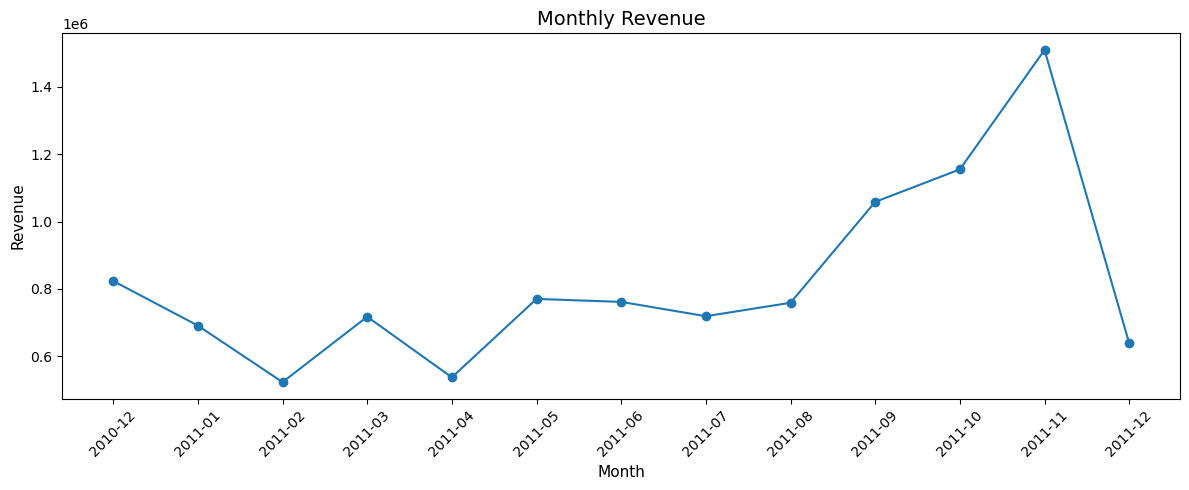

,YearMonth,Revenue
0,2010-12,823746.140
1,2011-01,691364.560
2,2011-02,523631.890
3,2011-03,717639.360
4,2011-04,537808.621
5,2011-05,770536.020
6,2011-06,761739.900
7,2011-07,719221.191
8,2011-08,759138.380
9,2011-09,1058590.172


In [5]:
monthly_revenue = (
    sales.groupby("YearMonth", as_index=False)["Revenue"]
    .sum()
    .sort_values("YearMonth")
)

plt.figure(figsize=(12, 5))
plt.plot(monthly_revenue["YearMonth"], monthly_revenue["Revenue"], marker="o")
plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

monthly_revenue

### Notes: from observation to insight

**Possible observation**
- Revenue generally rises over time, with a strong peak near the end of the year.

**Possible insight**
- Demand appears seasonal, suggesting holiday effects and year-end concentration in sales.

**Possible business action**
- Prepare inventory, staffing, and promotions before the peak months.

### In-class question
What additional information would you want before concluding this is seasonality rather than one-time promotion?

## 5. Visual 2 — Revenue by country

A simple bar chart can uncover concentration risk.

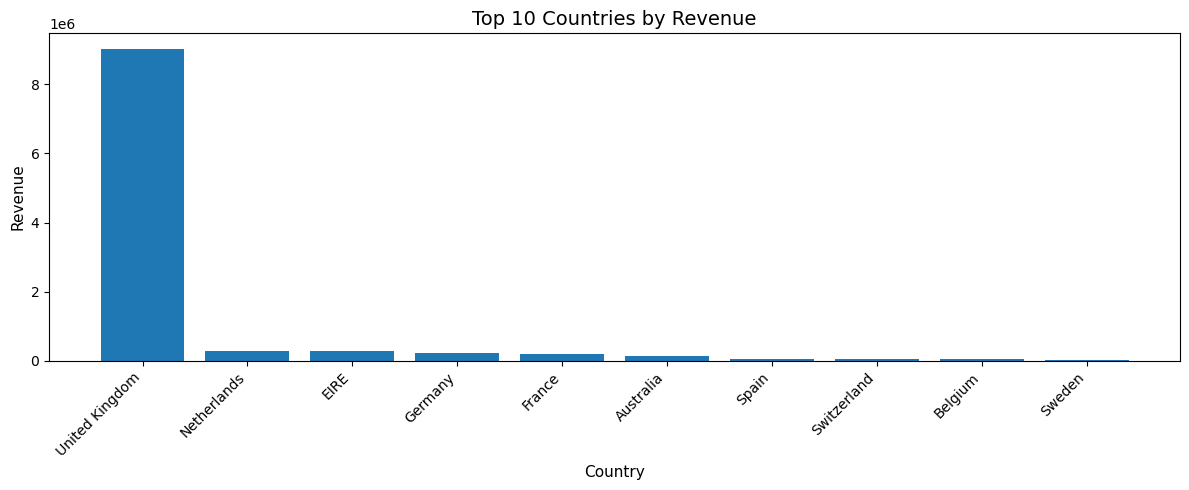

,Country,Revenue
36,United Kingdom,9025222.084
24,Netherlands,285446.340
10,EIRE,283453.960
14,Germany,228867.140
13,France,209715.110
0,Australia,138521.310
31,Spain,61577.110
33,Switzerland,57089.900
3,Belgium,41196.340
32,Sweden,38378.330


In [6]:
country_revenue = (
    sales.groupby("Country", as_index=False)["Revenue"]
    .sum()
    .sort_values("Revenue", ascending=False)
)

top_country_revenue = country_revenue.head(10)

plt.figure(figsize=(12, 5))
plt.bar(top_country_revenue["Country"], top_country_revenue["Revenue"])
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

top_country_revenue

### Notes

**Possible observation**
- One or a few countries contribute disproportionately to total revenue.

**Possible insight**
- Revenue may be concentrated in a small number of markets, which creates both opportunity and dependency risk.

**Possible business action**
- Protect the core market while testing expansion strategies in secondary markets.

### Extension
Calculating the percentage of total revenue contributed by the top 3 countries.

In [7]:
top3_share = top_country_revenue.head(3)["Revenue"].sum() / country_revenue["Revenue"].sum()
print(f"Top 3 countries share of revenue: {top3_share:.2%}")

Top 3 countries share of revenue: 89.94%


## 6. Visual 3 — Top products by revenue

This chart helps you see that “best-selling” can be defined in different ways:
- by quantity
- by revenue
- by profit (if margin data exists)

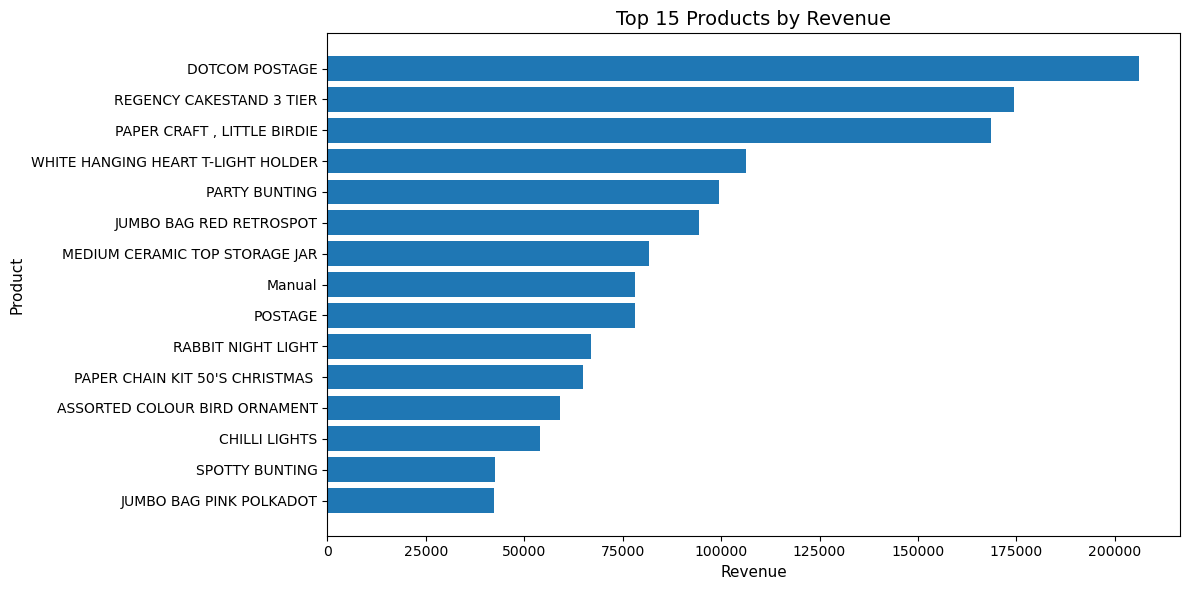

,Description,Revenue
1067,DOTCOM POSTAGE,206248.77
2853,REGENCY CAKESTAND 3 TIER,174484.74
2387,"PAPER CRAFT , LITTLE BIRDIE",168469.60
3844,WHITE HANGING HEART T-LIGHT HOLDER,106292.77
2413,PARTY BUNTING,99504.33
1816,JUMBO BAG RED RETROSPOT,94340.05
2052,MEDIUM CERAMIC TOP STORAGE JAR,81700.92
2192,Manual,78112.82
2692,POSTAGE,78101.88
2741,RABBIT NIGHT LIGHT,66964.99


In [8]:
product_revenue = (
    sales.groupby("Description", as_index=False)["Revenue"]
    .sum()
    .sort_values("Revenue", ascending=False)
)

top_products = product_revenue.head(15)

plt.figure(figsize=(12, 6))
plt.barh(top_products["Description"][::-1], top_products["Revenue"][::-1])
plt.title("Top 15 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

top_products.head(10)

### Notes

**Possible observation**
- A small number of products account for a large amount of revenue.

**Possible insight**
- Product performance is likely uneven; a few items may be driving the business.

**Possible business action**
- Protect high-performing products from stockouts and review the long tail of underperforming items.

### Insight question
Would you make the same decision if this chart showed **quantity** instead of **revenue**?

## 7. Visual 4 — Returns as a business signal

Returns are not just a data-cleaning issue. They can be a managerial insight.

Intuitively, the return should have a possitive relation to the sales volumn/revenue. 
This visual should somehow similar to the total revenue chart we developed in visual 1. 

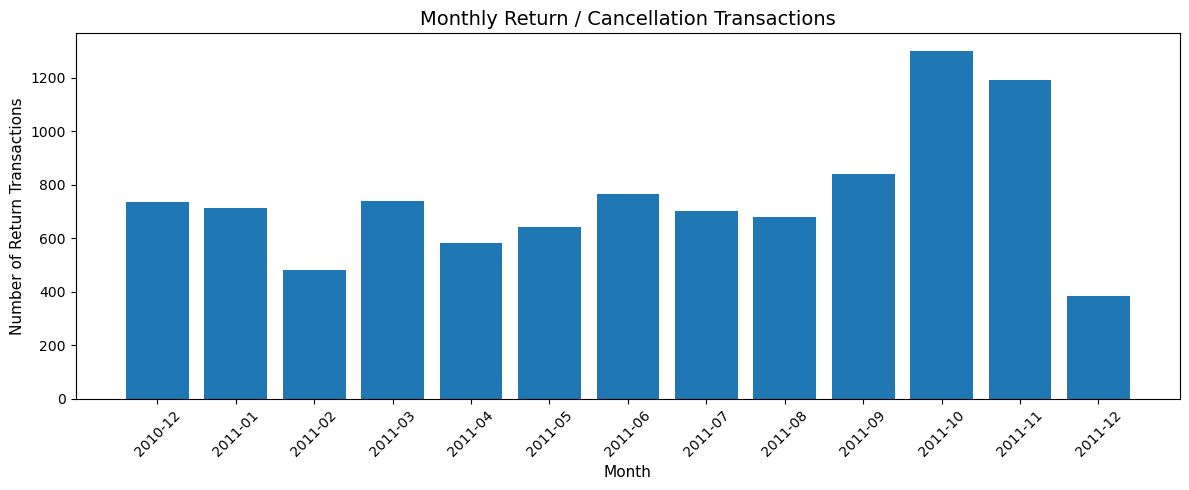

,YearMonth,ReturnTransactions
0,2010-12,736
1,2011-01,714
2,2011-02,483
3,2011-03,740
4,2011-04,582
5,2011-05,642
6,2011-06,765
7,2011-07,702
8,2011-08,678
9,2011-09,842


In [9]:
monthly_returns = (
    df[df["IsReturn"]]
    .assign(YearMonth=df["InvoiceDate"].dt.to_period("M").astype(str))
    .groupby("YearMonth", as_index=False)["InvoiceNo"]
    .count()
    .rename(columns={"InvoiceNo": "ReturnTransactions"})
    .sort_values("YearMonth")
)

plt.figure(figsize=(12, 5))
plt.bar(monthly_returns["YearMonth"], monthly_returns["ReturnTransactions"])
plt.title("Monthly Return / Cancellation Transactions")
plt.xlabel("Month")
plt.ylabel("Number of Return Transactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

monthly_returns

### Notes

**Possible observation**
- Some months have noticeably more return/cancellation activity.

**Possible insight**
- Returns may increase during high-volume periods, which can create hidden operational costs.

**Possible business action**
- Investigate return reasons, product quality issues, packaging problems, or customer expectation gaps.

### Classroom prompt
Why is it dangerous to study revenue without looking at returns?

## 8. Visual 5 — Price vs quantity relationship

Scatter plots are useful when we want to move from category comparison to relationships.

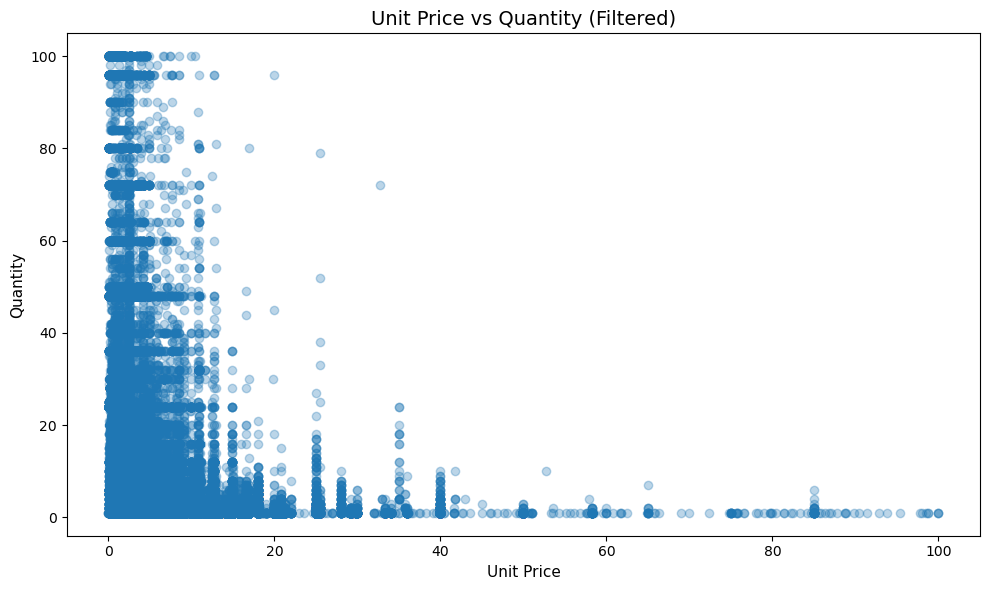

In [10]:
scatter_df = sales[(sales["Quantity"] <= 100) & (sales["UnitPrice"] <= 100)].copy()

plt.figure(figsize=(10, 6))
plt.scatter(scatter_df["UnitPrice"], scatter_df["Quantity"], alpha=0.3)
plt.title("Unit Price vs Quantity (Filtered)")
plt.xlabel("Unit Price")
plt.ylabel("Quantity")
plt.tight_layout()
plt.show()

### Notes

**Possible observation**
- Many transactions cluster at lower prices, and large quantities appear more often in lower-priced items.

**Possible insight**
- Demand may be more volume-driven in low-price products, while high-price items move in smaller quantities.

**Possible business action**
- Consider different pricing and promotion strategies for low-price/high-volume vs high-price/low-volume products.

### Important warning
A scatter plot may suggest a pattern, but it does **not** automatically prove causation.

## 9. Build a mini insight summary table

This section is useful for teaching students how to write about visuals.

In [11]:
summary = pd.DataFrame({
    "Visual": [
        "Monthly revenue trend",
        "Revenue by country",
        "Top products by revenue",
        "Monthly return transactions",
        "Unit price vs quantity"
    ],
    "Observation": [
        "Revenue rises and peaks near year-end.",
        "Revenue is concentrated in a few countries.",
        "A small number of products dominate revenue.",
        "Returns increase in some periods.",
        "Lower-priced items often sell in larger quantities."
    ],
    "Insight": [
        "Sales likely have a seasonal pattern.",
        "The business depends heavily on a limited set of markets.",
        "Revenue concentration suggests a product portfolio imbalance.",
        "Returns create operational and financial drag.",
        "Different product price tiers may require different selling strategies."
    ],
    "Action": [
        "Plan inventory and staffing before peak periods.",
        "Protect strong markets and grow secondary ones.",
        "Prioritize top products and review weak ones.",
        "Investigate causes of returns and reduce them.",
        "Segment pricing and promotion strategies."
    ]
})

summary

,Visual,Observation,Insight,Action
0,Monthly revenue trend,Revenue rises and peaks near year-end.,Sales likely have a seasonal pattern.,Plan inventory and staffing before peak periods.
1,Revenue by country,Revenue is concentrated in a few countries.,The business depends heavily on a limited set ...,Protect strong markets and grow secondary ones.
2,Top products by revenue,A small number of products dominate revenue.,Revenue concentration suggests a product portf...,Prioritize top products and review weak ones.
3,Monthly return transactions,Returns increase in some periods.,Returns create operational and financial drag.,Investigate causes of returns and reduce them.
4,Unit price vs quantity,Lower-priced items often sell in larger quanti...,Different product price tiers may require diff...,Segment pricing and promotion strategies.


## 10. Wrap-up: Key take away

A useful way to conclude the notebook is:

> A visualization becomes valuable only when it leads to a meaningful interpretation and a business decision.

### Core lesson
When you review a visual, always ask youself:

1. **What do I see?**  
2. **Why does it matter?**  
3. **What should the business do?**

That is the movement from **visual** to **insight**.

## 11. Optional exercises

1. Compute monthly order counts and compare them with monthly revenue.  
2. Identify the top 10 products by **quantity** instead of revenue.  
3. Compare UK vs non-UK sales patterns.  
4. Calculate the share of transactions that are returns.  
5. Write three insight statements in this format:

- **Observation:** ...
- **Insight:** ...
- **Recommended action:** ...